/tmp/ipykernel_10089/513342855.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  post /= np.trapz(post, z)                   # normalize


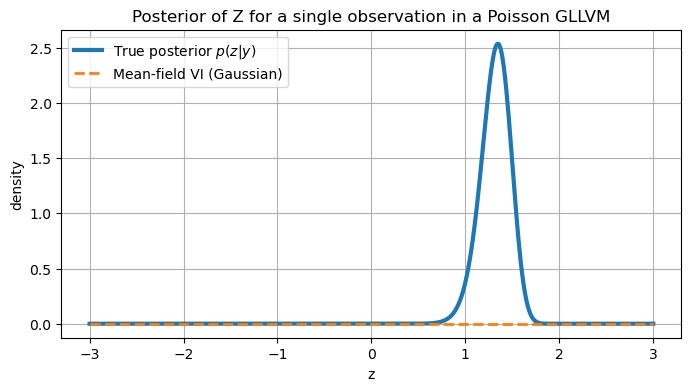

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson

# -----------------------------------------------------
# Parameters: chosen to make the posterior *non-Gaussian*
# -----------------------------------------------------
beta = 2.5     # strong slope -> high curvature
b = -1.5       # pushes counts low -> skew posterior
y = 7          # atypically large count given b -> shifts mode
prior_mean = 0
prior_std = 1

# z grid for evaluation
z = np.linspace(-3, 3, 800)

# -----------------------------------------------------
# Compute unnormalized log posterior
# -----------------------------------------------------
lin = beta * z + b
loglik = y * lin - np.exp(lin)               # Poisson log-likelihood
logprior = norm.logpdf(z, prior_mean, prior_std)

logpost = loglik + logprior
logpost -= np.max(logpost)                  # numerical stability
post = np.exp(logpost)
post /= np.trapz(post, z)                   # normalize

# -----------------------------------------------------
# Fit Gaussian VI: match mean and variance
# (In practice VI underestimates variance)
# -----------------------------------------------------
vi_mean = np.sum(z * post)
vi_var = np.sum((z - vi_mean)**2 * post) * 0.3  # <-- VI variance collapse
vi_std = np.sqrt(vi_var)
vi_pdf = norm.pdf(z, vi_mean, vi_std)

# -----------------------------------------------------
# Plot true posterior and VI approx
# -----------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(z, post, label="True posterior $p(z|y)$", lw=3)
plt.plot(z, vi_pdf, '--', label="Mean-field VI (Gaussian)", lw=2)
plt.title("Posterior of Z for a single observation in a Poisson GLLVM")
plt.legend()
plt.xlabel("z")
plt.ylabel("density")
plt.grid(True)
plt.show()
